<a href="https://www.kaggle.com/code/lalit7881/multi-channel-e-commerce-behavioral-dataset?scriptVersionId=310128734" target="_blank"><img align="left" alt="Kaggle" title="Open in Kaggle" src="https://kaggle.com/static/images/open-in-kaggle.svg"></a>

In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)
import seaborn as sns
import warnings
warnings.filterwarnings("ignore")
import matplotlib.pyplot as plt
# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/datasets/rifatalam3/multi-channel-e-commerce-with-behavioral-metrics/customer.csv


## Loading dataset

In [2]:
df = pd.read_csv("/kaggle/input/datasets/rifatalam3/multi-channel-e-commerce-with-behavioral-metrics/customer.csv")

In [3]:
df.head()

,CustomerID,Customer_Segment,Acquisition_Date,Age,Gender,Job_Category,Annual_Income,Education_Level,Marital_Status,Household_Size,...,Profitability_Score,Age_Group,Revenue_Tier,Seasonal_Factor,Purchase_Month,Purchase_Quarter,Purchase_Year,Days_Since_Acquisition,Acquisition_Month,Cohort_Index
0,C00001,Regular,2023-12-05,49,Female,Manufacturing,53900,Bachelor,Single,2,...,2.04,46-60,Low,1.4,10,4,2024,316,2023-12,10
1,C00002,New,2023-01-26,39,Male,IT,47557,High School,Single,2,...,0.06,31-45,Low,0.9,4,2,2023,89,2023-01,3
2,C00003,Regular,2023-07-01,51,Female,Other,81597,High School,Widowed,2,...,0.66,46-60,Low,0.9,1,1,2023,-156,2023-07,-6
3,C00004,Regular,2023-09-22,64,Male,Finance,100299,Bachelor,Married,3,...,53.40,60+,Premium,1.4,10,4,2023,17,2023-09,1
4,C00005,New,2023-09-15,38,Female,Other,132438,Master,Married,2,...,7.24,31-45,High,1.4,9,3,2023,-7,2023-09,0


In [4]:
df.tail()

,CustomerID,Customer_Segment,Acquisition_Date,Age,Gender,Job_Category,Annual_Income,Education_Level,Marital_Status,Household_Size,...,Profitability_Score,Age_Group,Revenue_Tier,Seasonal_Factor,Purchase_Month,Purchase_Quarter,Purchase_Year,Days_Since_Acquisition,Acquisition_Month,Cohort_Index
49995,C49996,Regular,2023-03-05,42,Male,Healthcare,25000,Bachelor,Married,3,...,8.39,31-45,Medium,1.4,7,3,2024,499,2023-03,16
49996,C49997,VIP,2023-04-26,41,Male,Manufacturing,36221,High School,Married,1,...,15.65,31-45,Premium,1.4,10,4,2024,554,2023-04,18
49997,C49998,New,2023-11-23,49,Male,Education,41384,Bachelor,Divorced,2,...,11.31,46-60,High,1.4,6,2,2024,219,2023-11,7
49998,C49999,New,2023-12-01,45,Male,IT,25344,Bachelor,Married,2,...,1.37,31-45,Low,1.1,5,2,2024,173,2023-12,5
49999,C50000,VIP,2023-10-12,64,Male,IT,44563,Master,Widowed,1,...,8.31,60+,Premium,1.2,9,3,2023,-38,2023-10,-1


In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 50000 entries, 0 to 49999
Data columns (total 53 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   CustomerID                 50000 non-null  object 
 1   Customer_Segment           50000 non-null  object 
 2   Acquisition_Date           50000 non-null  object 
 3   Age                        50000 non-null  int64  
 4   Gender                     50000 non-null  object 
 5   Job_Category               50000 non-null  object 
 6   Annual_Income              50000 non-null  int64  
 7   Education_Level            50000 non-null  object 
 8   Marital_Status             50000 non-null  object 
 9   Household_Size             50000 non-null  int64  
 10  Product                    50000 non-null  object 
 11  Quantity                   50000 non-null  int64  
 12  Unit_Price                 50000 non-null  float64
 13  Discount_Applied           50000 non-null  flo

In [6]:
df.describe()

,Age,Annual_Income,Household_Size,Quantity,Unit_Price,Discount_Applied,Revenue,Customer_Lifetime_Value,Profit_Margin,Loyalty_Score,...,Revenue_per_Unit,CLV_to_CAC_Ratio,Engagement_Score,Profitability_Score,Seasonal_Factor,Purchase_Month,Purchase_Quarter,Purchase_Year,Days_Since_Acquisition,Cohort_Index
count,50000.000000,50000.000000,50000.000000,50000.000000,50000.000000,50000.000000,50000.000000,50000.00000,50000.000000,50000.000000,...,50000.000000,50000.000000,50000.000000,50000.000000,50000.00000,50000.000000,50000.000000,50000.000000,50000.000000,50000.000000
mean,41.867540,62028.001400,2.574480,2.125100,75.038502,0.201286,1546.695360,22082.72410,0.400438,28.457870,...,982.330150,279.896133,0.493995,7.849424,1.15149,6.509140,2.504680,2023.503480,182.882380,5.999260
std,14.211443,40069.114311,1.457647,1.254385,70.262045,0.121185,1769.129019,23168.23692,0.201129,15.901923,...,1339.216853,347.961020,0.124383,12.449872,0.17979,3.458271,1.118965,0.499993,236.559626,7.750542
min,18.000000,25000.000000,1.000000,1.000000,10.000000,0.000000,100.000000,31.00000,0.002000,0.100000,...,12.500000,0.200000,0.127000,0.000000,0.90000,1.000000,1.000000,2023.000000,-362.000000,-12.000000
25%,31.000000,28914.000000,1.000000,1.000000,31.780000,0.108000,424.000000,7537.75000,0.242000,16.100000,...,212.000000,75.747500,0.403000,1.320000,1.10000,4.000000,2.000000,2023.000000,0.000000,0.000000
50%,42.000000,50725.500000,2.000000,2.000000,54.340000,0.181000,940.000000,14781.50000,0.385000,26.400000,...,516.000000,165.720000,0.507000,3.590000,1.20000,7.000000,3.000000,2024.000000,183.000000,6.000000
75%,52.000000,80999.500000,3.000000,3.000000,93.390000,0.274000,1951.000000,28016.25000,0.545000,38.800000,...,1174.082500,343.490000,0.584000,9.000000,1.40000,10.000000,4.000000,2024.000000,366.000000,12.000000
max,85.000000,250000.000000,8.000000,11.000000,1000.000000,0.788000,10000.000000,277254.00000,0.974000,93.400000,...,10000.000000,4976.940000,0.919000,186.400000,1.40000,12.000000,4.000000,2024.000000,727.000000,23.000000


In [7]:
df.isnull().sum()

CustomerID                   0
Customer_Segment             0
Acquisition_Date             0
Age                          0
Gender                       0
Job_Category                 0
Annual_Income                0
Education_Level              0
Marital_Status               0
Household_Size               0
Product                      0
Quantity                     0
Unit_Price                   0
Discount_Applied             0
Payment_Method               0
Revenue                      0
Customer_Lifetime_Value      0
Profit_Margin                0
Loyalty_Score                0
Loyalty_Tier                 0
Customer_Satisfaction        0
Purchase_Frequency           0
Days_Since_Last_Purchase     0
Newsletter_Subscribed        0
Support_Tickets              0
Email_Open_Rate              0
Social_Media_Engagement      0
Purchase_Date                0
Purchase_Hour                0
Season                       0
Is_Weekend                   0
Days_to_Next_Purchase        0
Churned 

In [8]:
df.duplicated().sum()

np.int64(0)

In [9]:
df.dtypes

CustomerID                    object
Customer_Segment              object
Acquisition_Date              object
Age                            int64
Gender                        object
Job_Category                  object
Annual_Income                  int64
Education_Level               object
Marital_Status                object
Household_Size                 int64
Product                       object
Quantity                       int64
Unit_Price                   float64
Discount_Applied             float64
Payment_Method                object
Revenue                        int64
Customer_Lifetime_Value        int64
Profit_Margin                float64
Loyalty_Score                float64
Loyalty_Tier                  object
Customer_Satisfaction        float64
Purchase_Frequency             int64
Days_Since_Last_Purchase       int64
Newsletter_Subscribed          int64
Support_Tickets                int64
Email_Open_Rate              float64
Social_Media_Engagement      float64
P

In [10]:
df.shape

(50000, 53)

In [11]:
df.dtypes

CustomerID                    object
Customer_Segment              object
Acquisition_Date              object
Age                            int64
Gender                        object
Job_Category                  object
Annual_Income                  int64
Education_Level               object
Marital_Status                object
Household_Size                 int64
Product                       object
Quantity                       int64
Unit_Price                   float64
Discount_Applied             float64
Payment_Method                object
Revenue                        int64
Customer_Lifetime_Value        int64
Profit_Margin                float64
Loyalty_Score                float64
Loyalty_Tier                  object
Customer_Satisfaction        float64
Purchase_Frequency             int64
Days_Since_Last_Purchase       int64
Newsletter_Subscribed          int64
Support_Tickets                int64
Email_Open_Rate              float64
Social_Media_Engagement      float64
P

In [12]:
df.columns

Index(['CustomerID', 'Customer_Segment', 'Acquisition_Date', 'Age', 'Gender',
       'Job_Category', 'Annual_Income', 'Education_Level', 'Marital_Status',
       'Household_Size', 'Product', 'Quantity', 'Unit_Price',
       'Discount_Applied', 'Payment_Method', 'Revenue',
       'Customer_Lifetime_Value', 'Profit_Margin', 'Loyalty_Score',
       'Loyalty_Tier', 'Customer_Satisfaction', 'Purchase_Frequency',
       'Days_Since_Last_Purchase', 'Newsletter_Subscribed', 'Support_Tickets',
       'Email_Open_Rate', 'Social_Media_Engagement', 'Purchase_Date',
       'Purchase_Hour', 'Season', 'Is_Weekend', 'Days_to_Next_Purchase',
       'Churned', 'Churn_Risk_Score', 'Return_Rate', 'Payment_Delay_Days',
       'Customer_Acquisition_Cost', 'Marketing_Channel',
       'First_Purchase_Channel', 'Net_Revenue', 'Revenue_per_Unit',
       'CLV_to_CAC_Ratio', 'Engagement_Score', 'Profitability_Score',
       'Age_Group', 'Revenue_Tier', 'Seasonal_Factor', 'Purchase_Month',
       'Purchase_Quarter

In [13]:
df.nunique()

CustomerID                   50000
Customer_Segment                 3
Acquisition_Date               366
Age                             68
Gender                           3
Job_Category                     7
Annual_Income                33065
Education_Level                  4
Marital_Status                   4
Household_Size                   8
Product                          5
Quantity                        11
Unit_Price                   16492
Discount_Applied               693
Payment_Method                   4
Revenue                       6296
Customer_Lifetime_Value      30505
Profit_Margin                  960
Loyalty_Score                  844
Loyalty_Tier                     4
Customer_Satisfaction           41
Purchase_Frequency              30
Days_Since_Last_Purchase       243
Newsletter_Subscribed            2
Support_Tickets                 15
Email_Open_Rate                962
Social_Media_Engagement        864
Purchase_Date                  731
Purchase_Hour       

## EDA

In [14]:
# Convert dates
df['Purchase_Date'] = pd.to_datetime(df['Purchase_Date'])
df['Acquisition_Date'] = pd.to_datetime(df['Acquisition_Date'])

# Handle missing values (simple approach)
df.fillna(method='ffill', inplace=True)

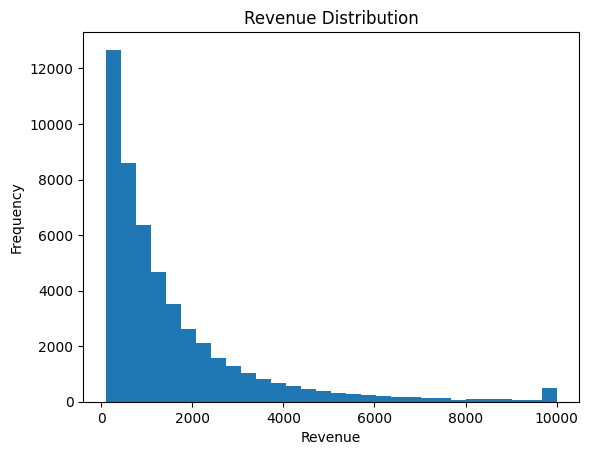

In [15]:
plt.figure()
plt.hist(df['Revenue'], bins=30)
plt.title("Revenue Distribution")
plt.xlabel("Revenue")
plt.ylabel("Frequency")
plt.show()

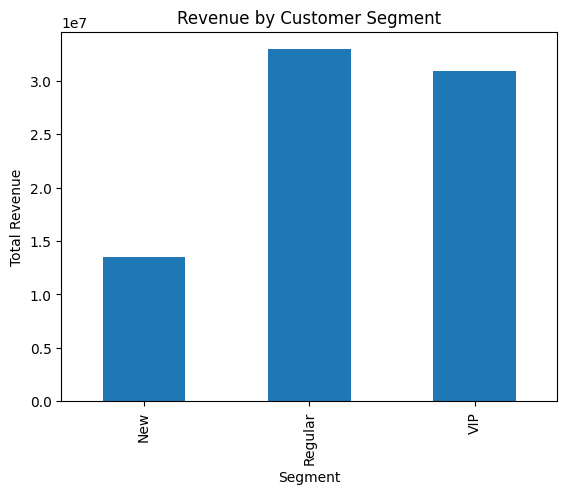

In [16]:
segment_rev = df.groupby('Customer_Segment')['Revenue'].sum()

plt.figure()
segment_rev.plot(kind='bar')
plt.title("Revenue by Customer Segment")
plt.xlabel("Segment")
plt.ylabel("Total Revenue")
plt.show()

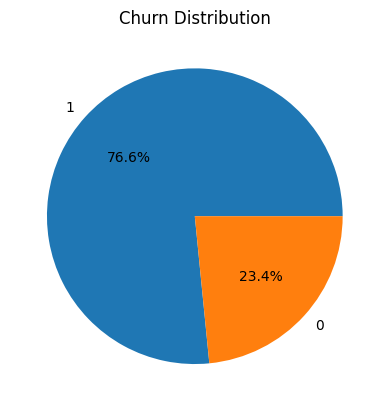

In [17]:
churn_counts = df['Churned'].value_counts()

plt.figure()
churn_counts.plot(kind='pie', autopct='%1.1f%%')
plt.title("Churn Distribution")
plt.ylabel("")
plt.show()

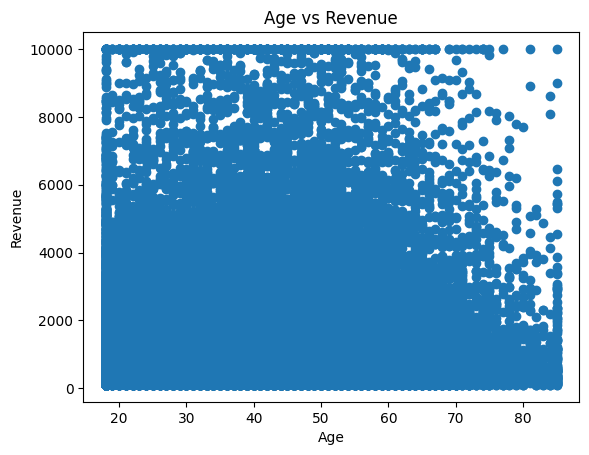

In [18]:
plt.figure()
plt.scatter(df['Age'], df['Revenue'])
plt.title("Age vs Revenue")
plt.xlabel("Age")
plt.ylabel("Revenue")
plt.show()

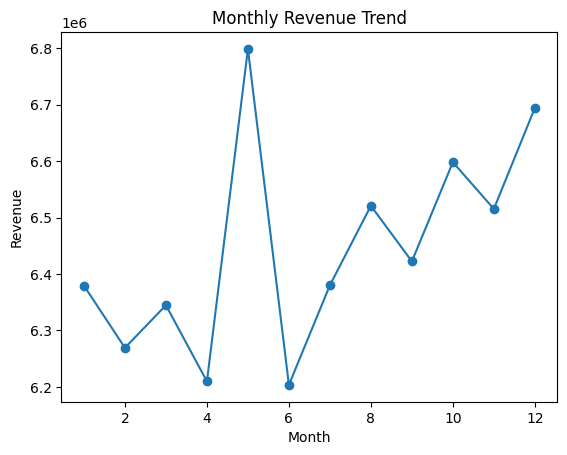

In [19]:
monthly_rev = df.groupby('Purchase_Month')['Revenue'].sum()

plt.figure()
monthly_rev.plot(kind='line', marker='o')
plt.title("Monthly Revenue Trend")
plt.xlabel("Month")
plt.ylabel("Revenue")
plt.show()

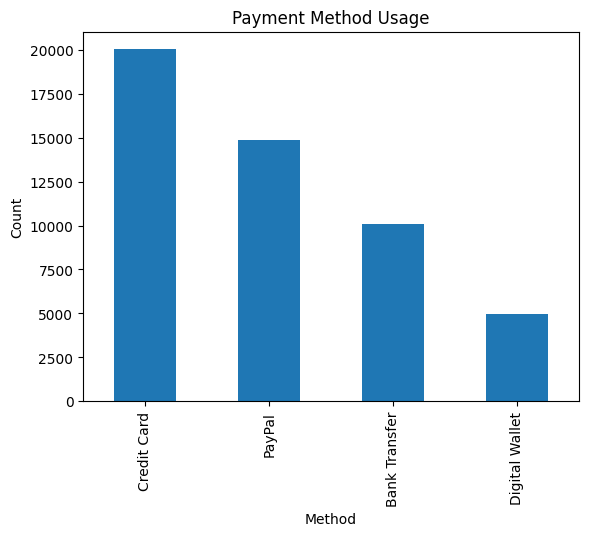

In [20]:
payment_counts = df['Payment_Method'].value_counts()

plt.figure()
payment_counts.plot(kind='bar')
plt.title("Payment Method Usage")
plt.xlabel("Method")
plt.ylabel("Count")
plt.show()

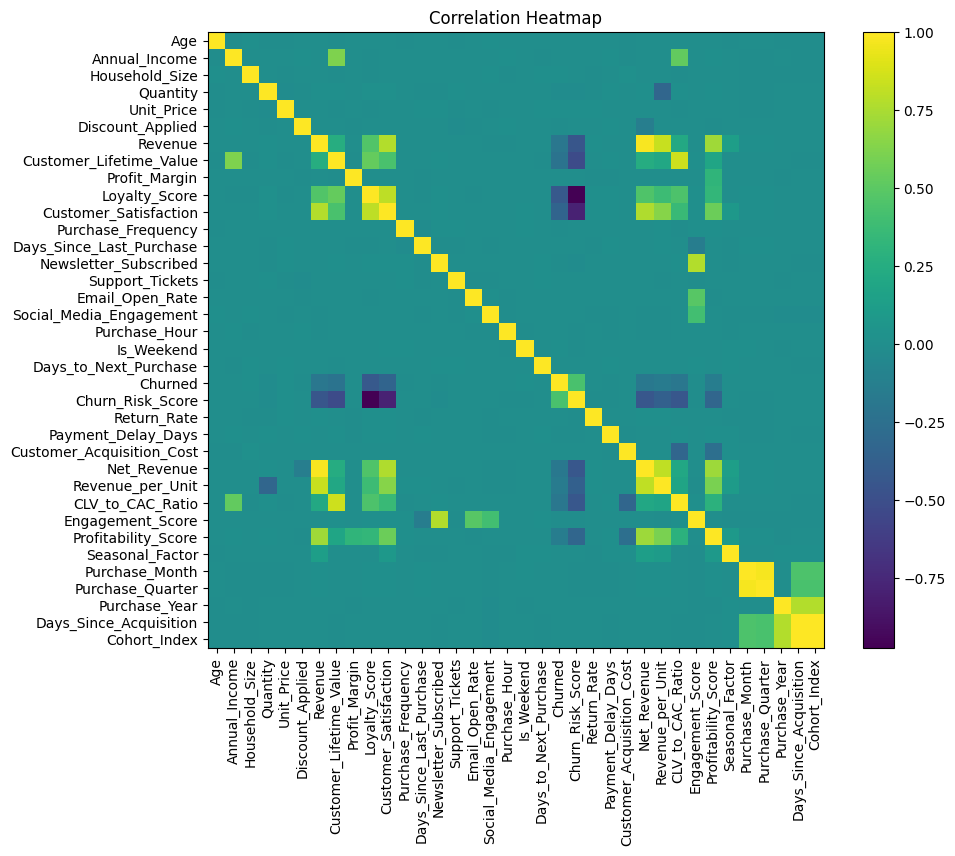

In [21]:
import numpy as np

numeric_cols = df.select_dtypes(include=np.number)

corr = numeric_cols.corr()

plt.figure(figsize=(10,8))
plt.imshow(corr)
plt.colorbar()
plt.xticks(range(len(corr.columns)), corr.columns, rotation=90)
plt.yticks(range(len(corr.columns)), corr.columns)
plt.title("Correlation Heatmap")
plt.show()

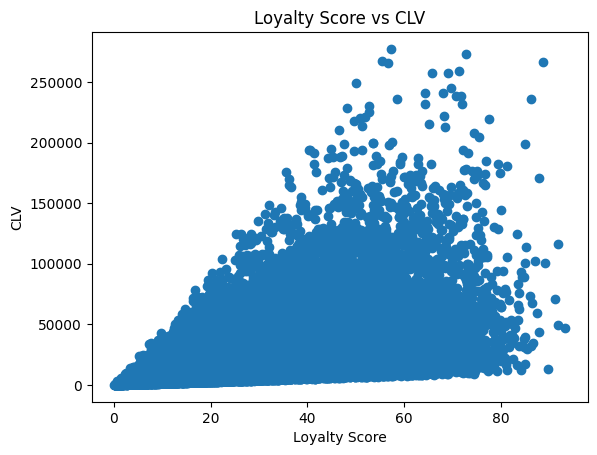

In [22]:
plt.figure()
plt.scatter(df['Loyalty_Score'], df['Customer_Lifetime_Value'])
plt.title("Loyalty Score vs CLV")
plt.xlabel("Loyalty Score")
plt.ylabel("CLV")
plt.show()

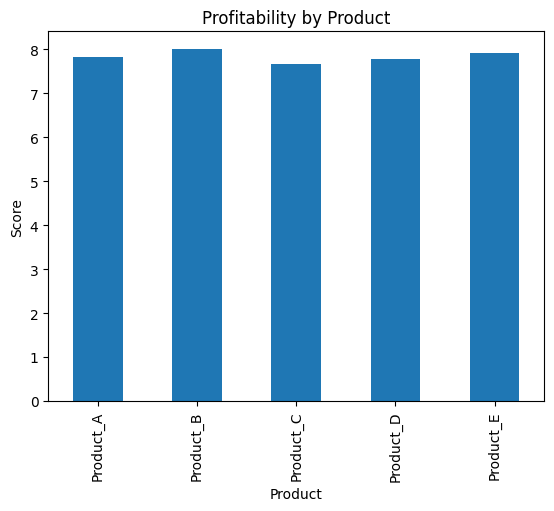

In [23]:
product_profit = df.groupby('Product')['Profitability_Score'].mean()

plt.figure()
product_profit.plot(kind='bar')
plt.title("Profitability by Product")
plt.xlabel("Product")
plt.ylabel("Score")
plt.show()

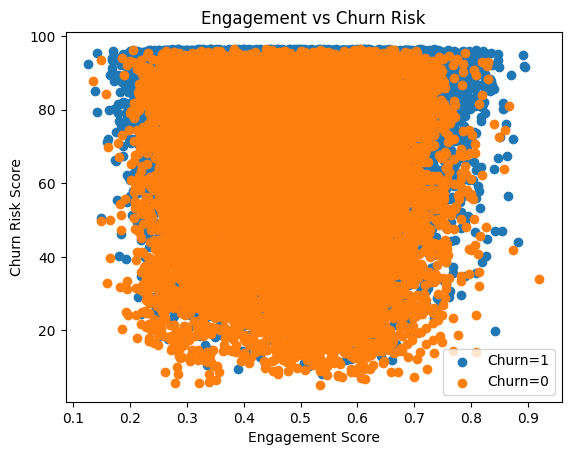

In [24]:
plt.figure()

for churn_value in df['Churned'].unique():
    subset = df[df['Churned'] == churn_value]
    plt.scatter(subset['Engagement_Score'], subset['Churn_Risk_Score'], label=f'Churn={churn_value}')

plt.title("Engagement vs Churn Risk")
plt.xlabel("Engagement Score")
plt.ylabel("Churn Risk Score")
plt.legend()
plt.show()

<Figure size 640x480 with 0 Axes>

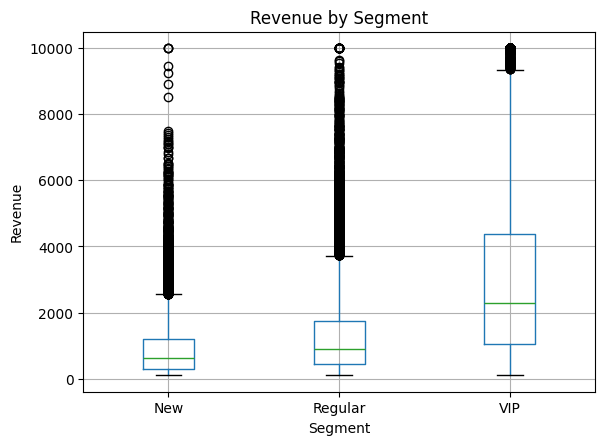

In [25]:
plt.figure()
df.boxplot(column='Revenue', by='Customer_Segment')
plt.title("Revenue by Segment")
plt.suptitle("")
plt.xlabel("Segment")
plt.ylabel("Revenue")
plt.show()

##  Feature engineering

In [26]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

from sklearn.metrics import accuracy_score, roc_auc_score, roc_curve

# Models
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.tree import DecisionTreeClassifier


In [27]:
print(df.head())

  CustomerID Customer_Segment Acquisition_Date  Age  Gender   Job_Category  \
0     C00001          Regular       2023-12-05   49  Female  Manufacturing   
1     C00002              New       2023-01-26   39    Male             IT   
2     C00003          Regular       2023-07-01   51  Female          Other   
3     C00004          Regular       2023-09-22   64    Male        Finance   
4     C00005              New       2023-09-15   38  Female          Other   

   Annual_Income Education_Level Marital_Status  Household_Size  ...  \
0          53900        Bachelor         Single               2  ...   
1          47557     High School         Single               2  ...   
2          81597     High School        Widowed               2  ...   
3         100299        Bachelor        Married               3  ...   
4         132438          Master        Married               2  ...   

  Profitability_Score  Age_Group  Revenue_Tier  Seasonal_Factor  \
0                2.04      46-6

In [28]:
target = 'Churned'

# Drop leakage-prone columns
drop_cols = [
    'CustomerID', 
    'Churn_Risk_Score',  # highly correlated with churn
    'Days_to_Next_Purchase'  # future info (leakage)
]

X = df.drop(columns=drop_cols + [target])
y = df[target]

In [29]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)


In [30]:
categorical_cols = X.select_dtypes(include=['object']).columns.tolist()
numeric_cols = X.select_dtypes(include=['int64', 'float64']).columns.tolist()

In [31]:
numeric_transformer = StandardScaler()

categorical_transformer = OneHotEncoder(handle_unknown='ignore')

preprocessor = ColumnTransformer(
    transformers=[
        ('num', numeric_transformer, numeric_cols),
        ('cat', categorical_transformer, categorical_cols)
    ]
)

In [32]:
models = {
    "Logistic Regression": LogisticRegression(max_iter=1000),
    "Decision Tree": DecisionTreeClassifier(max_depth=5),
    "Random Forest": RandomForestClassifier(n_estimators=100, random_state=42)
}

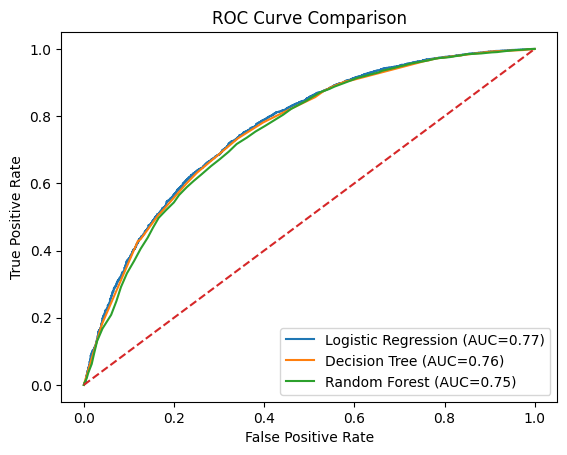

In [33]:
results = {}

plt.figure()

for name, model in models.items():
    
    # Create pipeline (preprocessing + model)
    pipeline = Pipeline(steps=[
        ('preprocessor', preprocessor),
        ('model', model)
    ])
    
    # Train ONLY on training data
    pipeline.fit(X_train, y_train)
    
    # Predictions
    y_pred = pipeline.predict(X_test)
    y_prob = pipeline.predict_proba(X_test)[:, 1]
    
    # Metrics
    acc = accuracy_score(y_test, y_pred)
    roc_auc = roc_auc_score(y_test, y_prob)
    
    results[name] = (acc, roc_auc)
    
    # ROC Curve
    fpr, tpr, _ = roc_curve(y_test, y_prob)
    plt.plot(fpr, tpr, label=f"{name} (AUC={roc_auc:.2f})")

# Plot ROC
plt.plot([0,1], [0,1], linestyle='--')
plt.title("ROC Curve Comparison")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.legend()
plt.show()

In [34]:
for model_name, (acc, roc_auc) in results.items():
    print(f"{model_name}")
    print(f"Accuracy: {acc:.4f}")
    print(f"ROC-AUC: {roc_auc:.4f}")
    print("-"*30)

Logistic Regression
Accuracy: 0.7985
ROC-AUC: 0.7654
------------------------------
Decision Tree
Accuracy: 0.7952
ROC-AUC: 0.7604
------------------------------
Random Forest
Accuracy: 0.7959
ROC-AUC: 0.7535
------------------------------


## Thank you..pls upvote!!!!!!